# Heart Disease Prediction
- To classify whether a person is prone to heart failure depending upon multiple attributes
- Binary classification Problem

## Import Libraries and Load Datasets

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [2]:
# Connect Collab with Kaggle
from google.colab import userdata
name = userdata.get("kaggle_username")
key = userdata.get("kaggle_key")

os.environ["KAGGLE_USERNAME"] = name
os.environ["KAGGLE_KEY"] = key

# Dataset Download
!kaggle datasets download fedesoriano/heart-failure-prediction

# Dataset Unzip
!unzip heart-failure-prediction.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
License(s): ODbL-1.0
heart-failure-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  heart-failure-prediction.zip
replace heart.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [3]:
# Load Data
heart_df = pd.read_csv("heart.csv")
print(heart_df.head(10))

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1     

## EDA

In [4]:
# Shape of data
heart_df.shape

(918, 12)

- This means there are 918 rows of data with 12 columns (features)

In [5]:
# Columns of the data
heart_df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
# Data Information
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Our dataset contains `918` patients records with `12` features

- Age: Patient's age in years
- Sex: Patient's Gender [M: Male, F: Female]
- ChestPainType: Type of Chest pain [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: Resting blood pressure [mm Hg]
- Cholesterol: Serum cholesterol level [mm/dl]
- FastingBS: Fasting blood sugar level [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: Resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR: Maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: Exercise-induced angina [Y: Yes, N: No]
- Oldpeak: Oldpeak = ST [Numeric value measured in depression]
- ST_Slope: The slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]

In [7]:
# Show Unique Values
heart_df.nunique()

,0
Age,50
Sex,2
ChestPainType,4
RestingBP,67
Cholesterol,222
FastingBS,2
RestingECG,3
MaxHR,119
ExerciseAngina,2
Oldpeak,53


In [8]:
# Summary Statistics of Data
heart_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
# Check for any missing values
heart_df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


- Data has no any NULL values

In [10]:
# Dividing Features into Numerical and Categorical
Categorical = heart_df.select_dtypes(include=['object'])
Numerical = heart_df.select_dtypes(include=['int64', 'float64'])


print('Categorical features:\n', Categorical)
print("\n-----------------------------------------------------\n")
print('Numerical features:\n', Numerical)

Categorical features:
     Sex ChestPainType RestingECG ExerciseAngina ST_Slope
0     M           ATA     Normal              N       Up
1     F           NAP     Normal              N     Flat
2     M           ATA         ST              N       Up
3     F           ASY     Normal              Y     Flat
4     M           NAP     Normal              N       Up
..   ..           ...        ...            ...      ...
913   M            TA     Normal              N     Flat
914   M           ASY     Normal              N     Flat
915   M           ASY     Normal              Y     Flat
916   F           ATA        LVH              N     Flat
917   M           NAP     Normal              N       Up

[918 rows x 5 columns]

-----------------------------------------------------

Numerical features:
      Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease
0     40        140          289          0    172      0.0             0
1     49        160          180          0 

In [11]:
# Count the target Variable
heart_df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


- This means there are 508 patients with heart disease and 410 patients without heart disease

## Visualisation

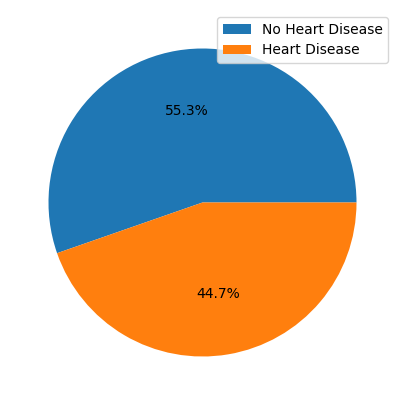

In [12]:
# Normal and Heart Disease with target column
plt.figure(figsize=(5,5))
plt.pie(heart_df['HeartDisease'].value_counts(),autopct='%1.1f%%')
plt.legend(['No Heart Disease','Heart Disease'], loc = "upper right")
plt.show()

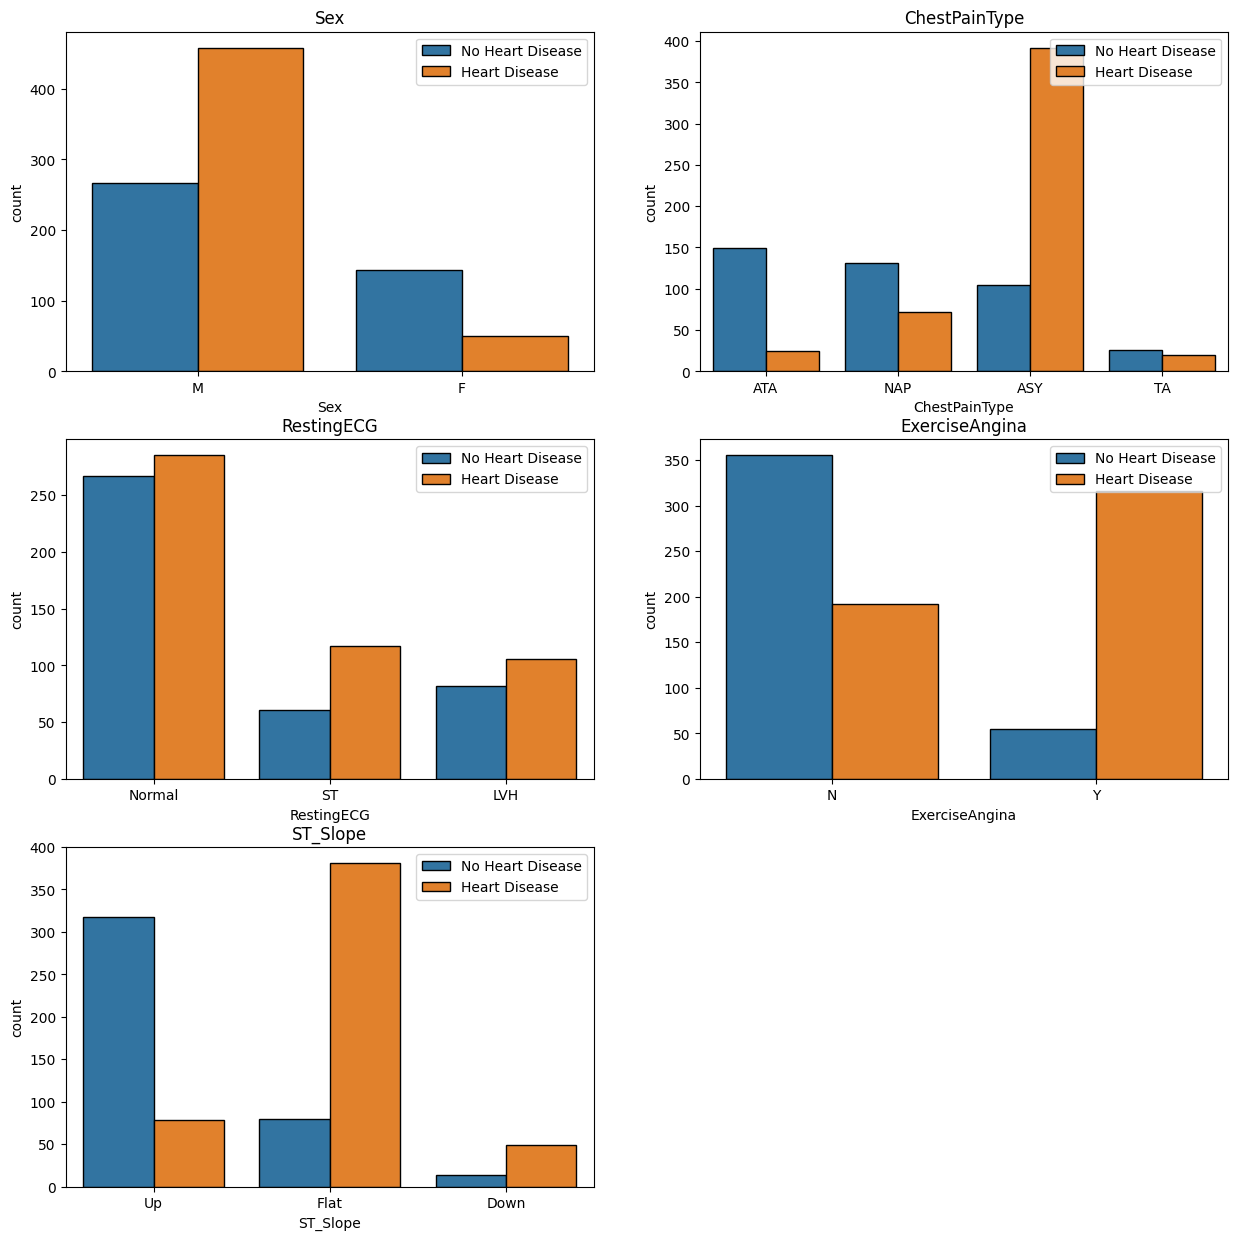

In [13]:
# Categorical Features vs Heart Disease
plt.figure(figsize=(15,15))

for i in Categorical:
  plt.subplot(3,2,Categorical.columns.get_loc(i)+1)
  sns.countplot(x=i,data=heart_df, hue='HeartDisease', edgecolor = "black")
  plt.legend(['No Heart Disease','Heart Disease'], loc = "upper right")
  plt.title(i)

plt.show()

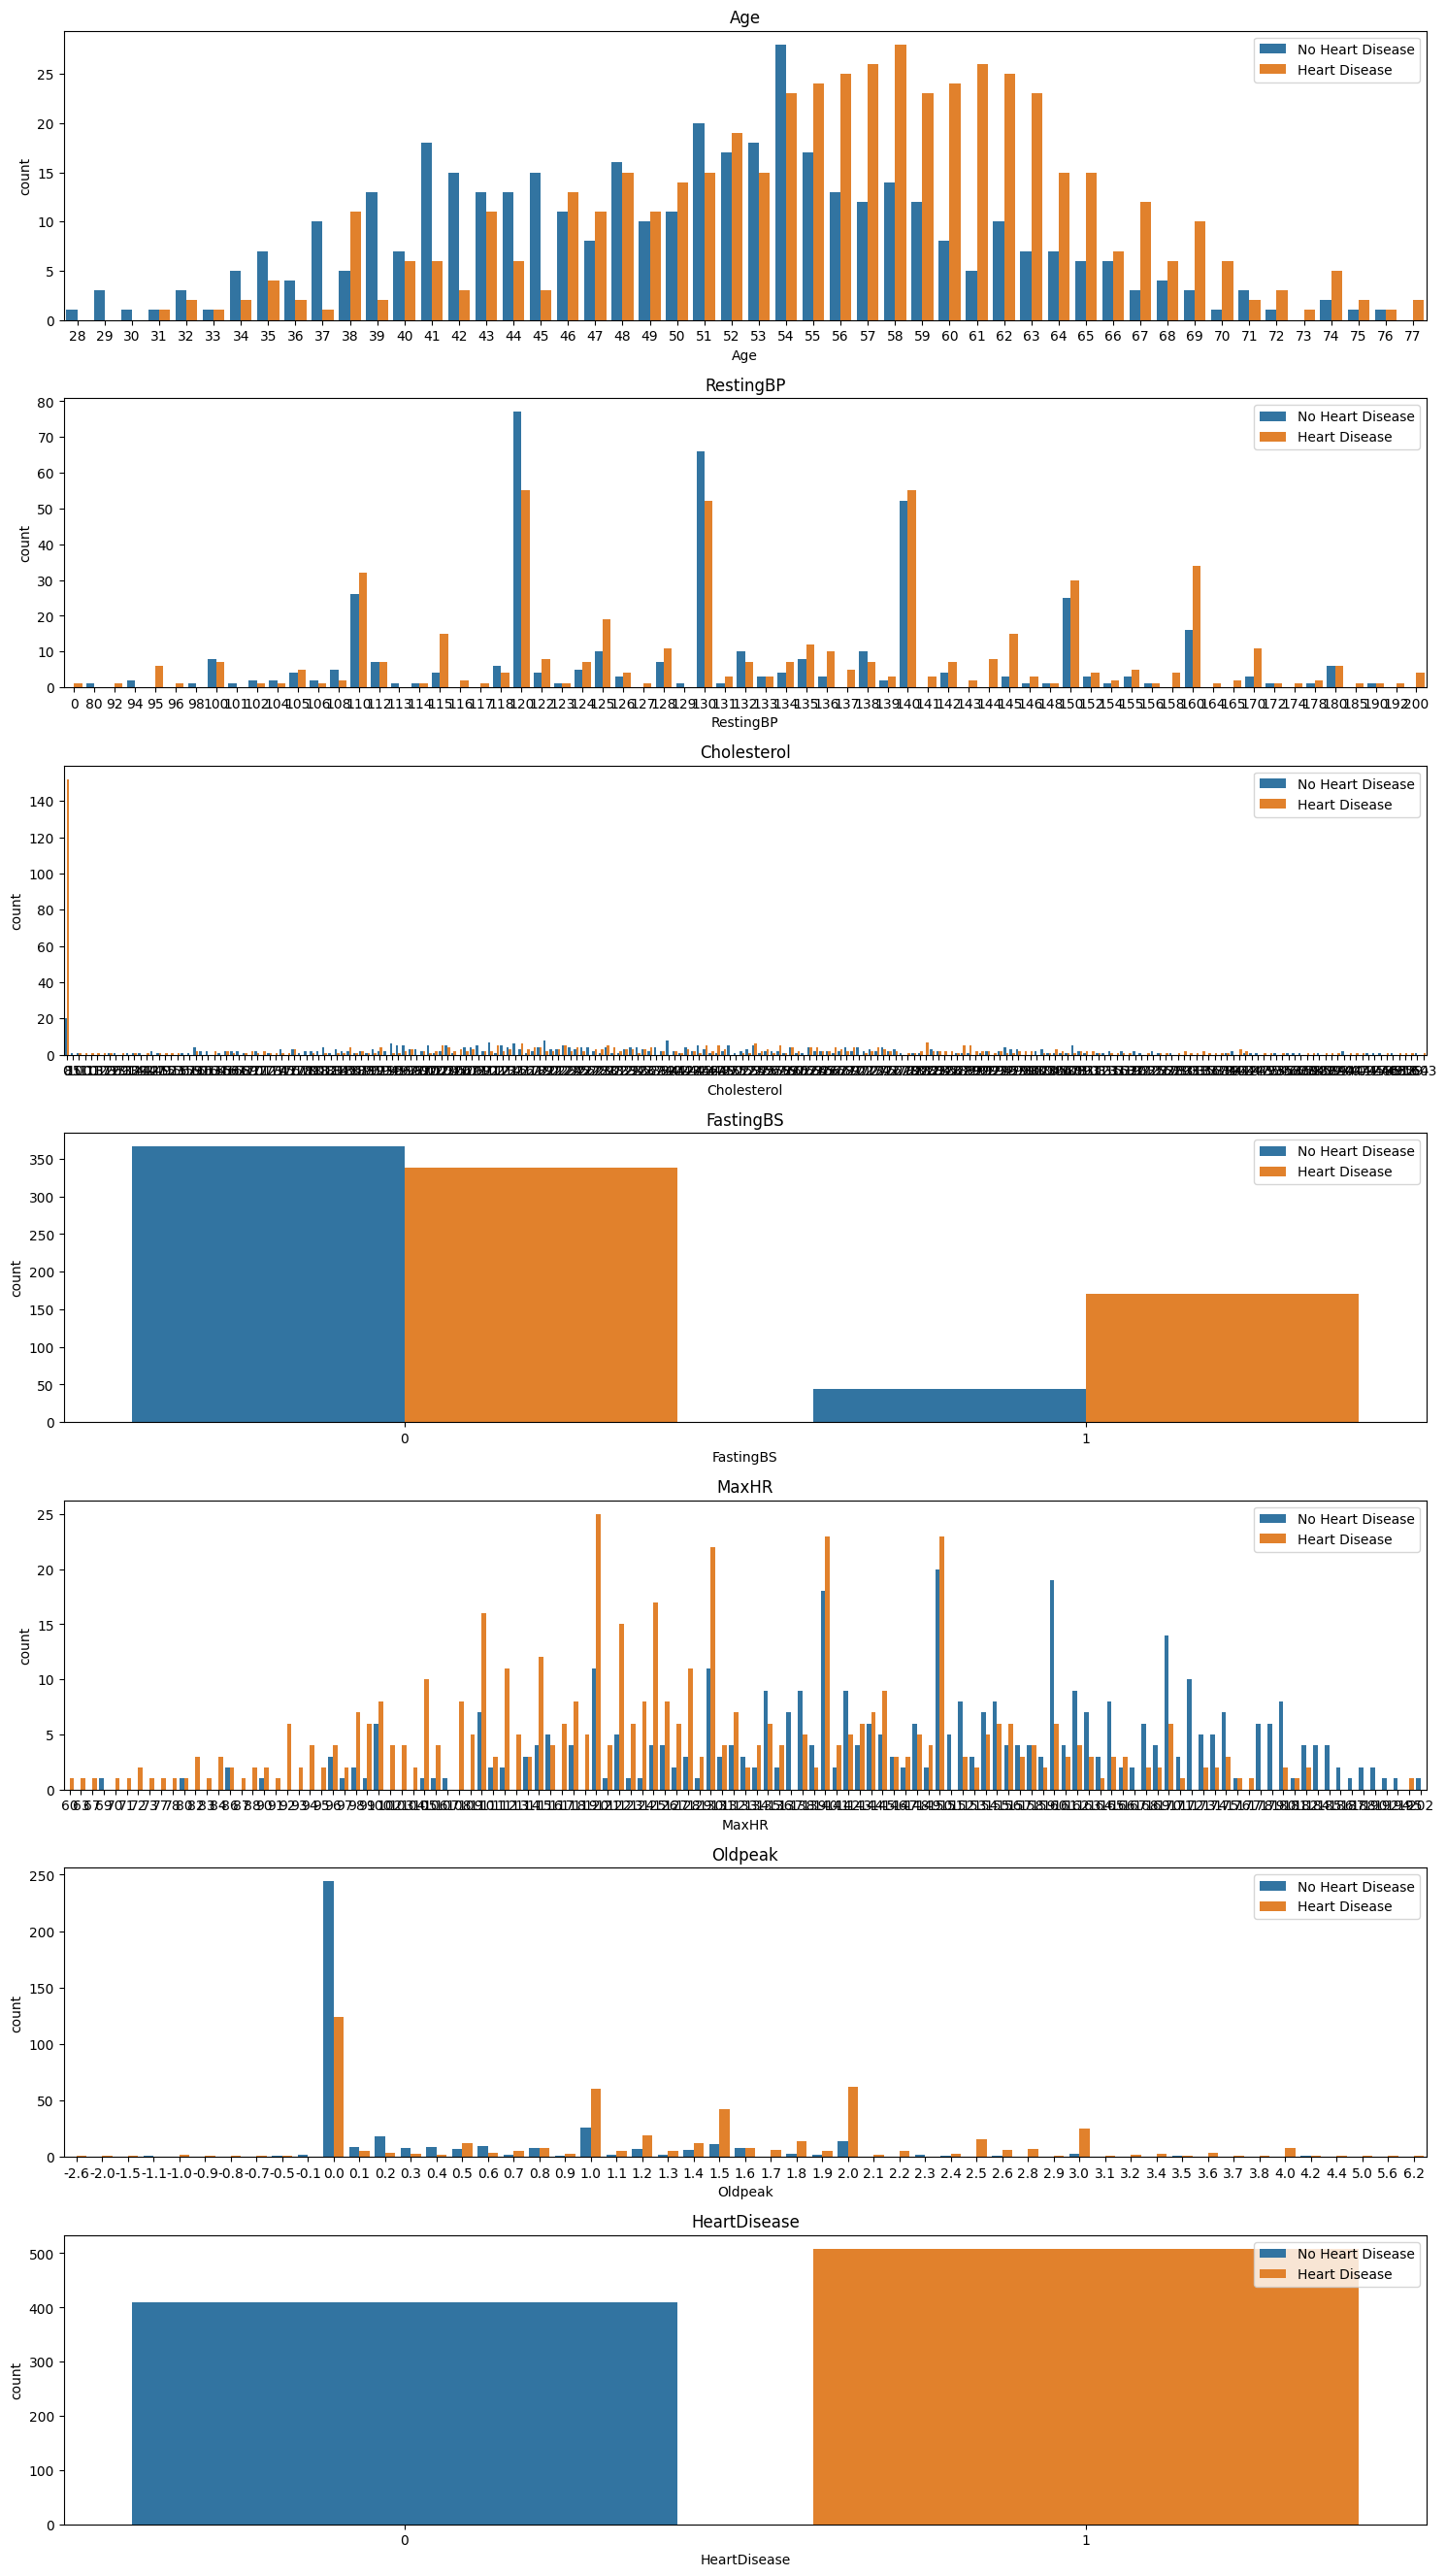

In [14]:
# Numerical Features vs Heart Disease
plt.figure(figsize=(15,30))

for i in Numerical:
  plt.subplot(8,1, Numerical.columns.get_loc(i)+1)
  sns.countplot(x=i,data=heart_df, hue='HeartDisease')
  plt.legend(['No Heart Disease','Heart Disease'], loc = "upper right")
  plt.title(i)
  plt.tight_layout()

plt.show()

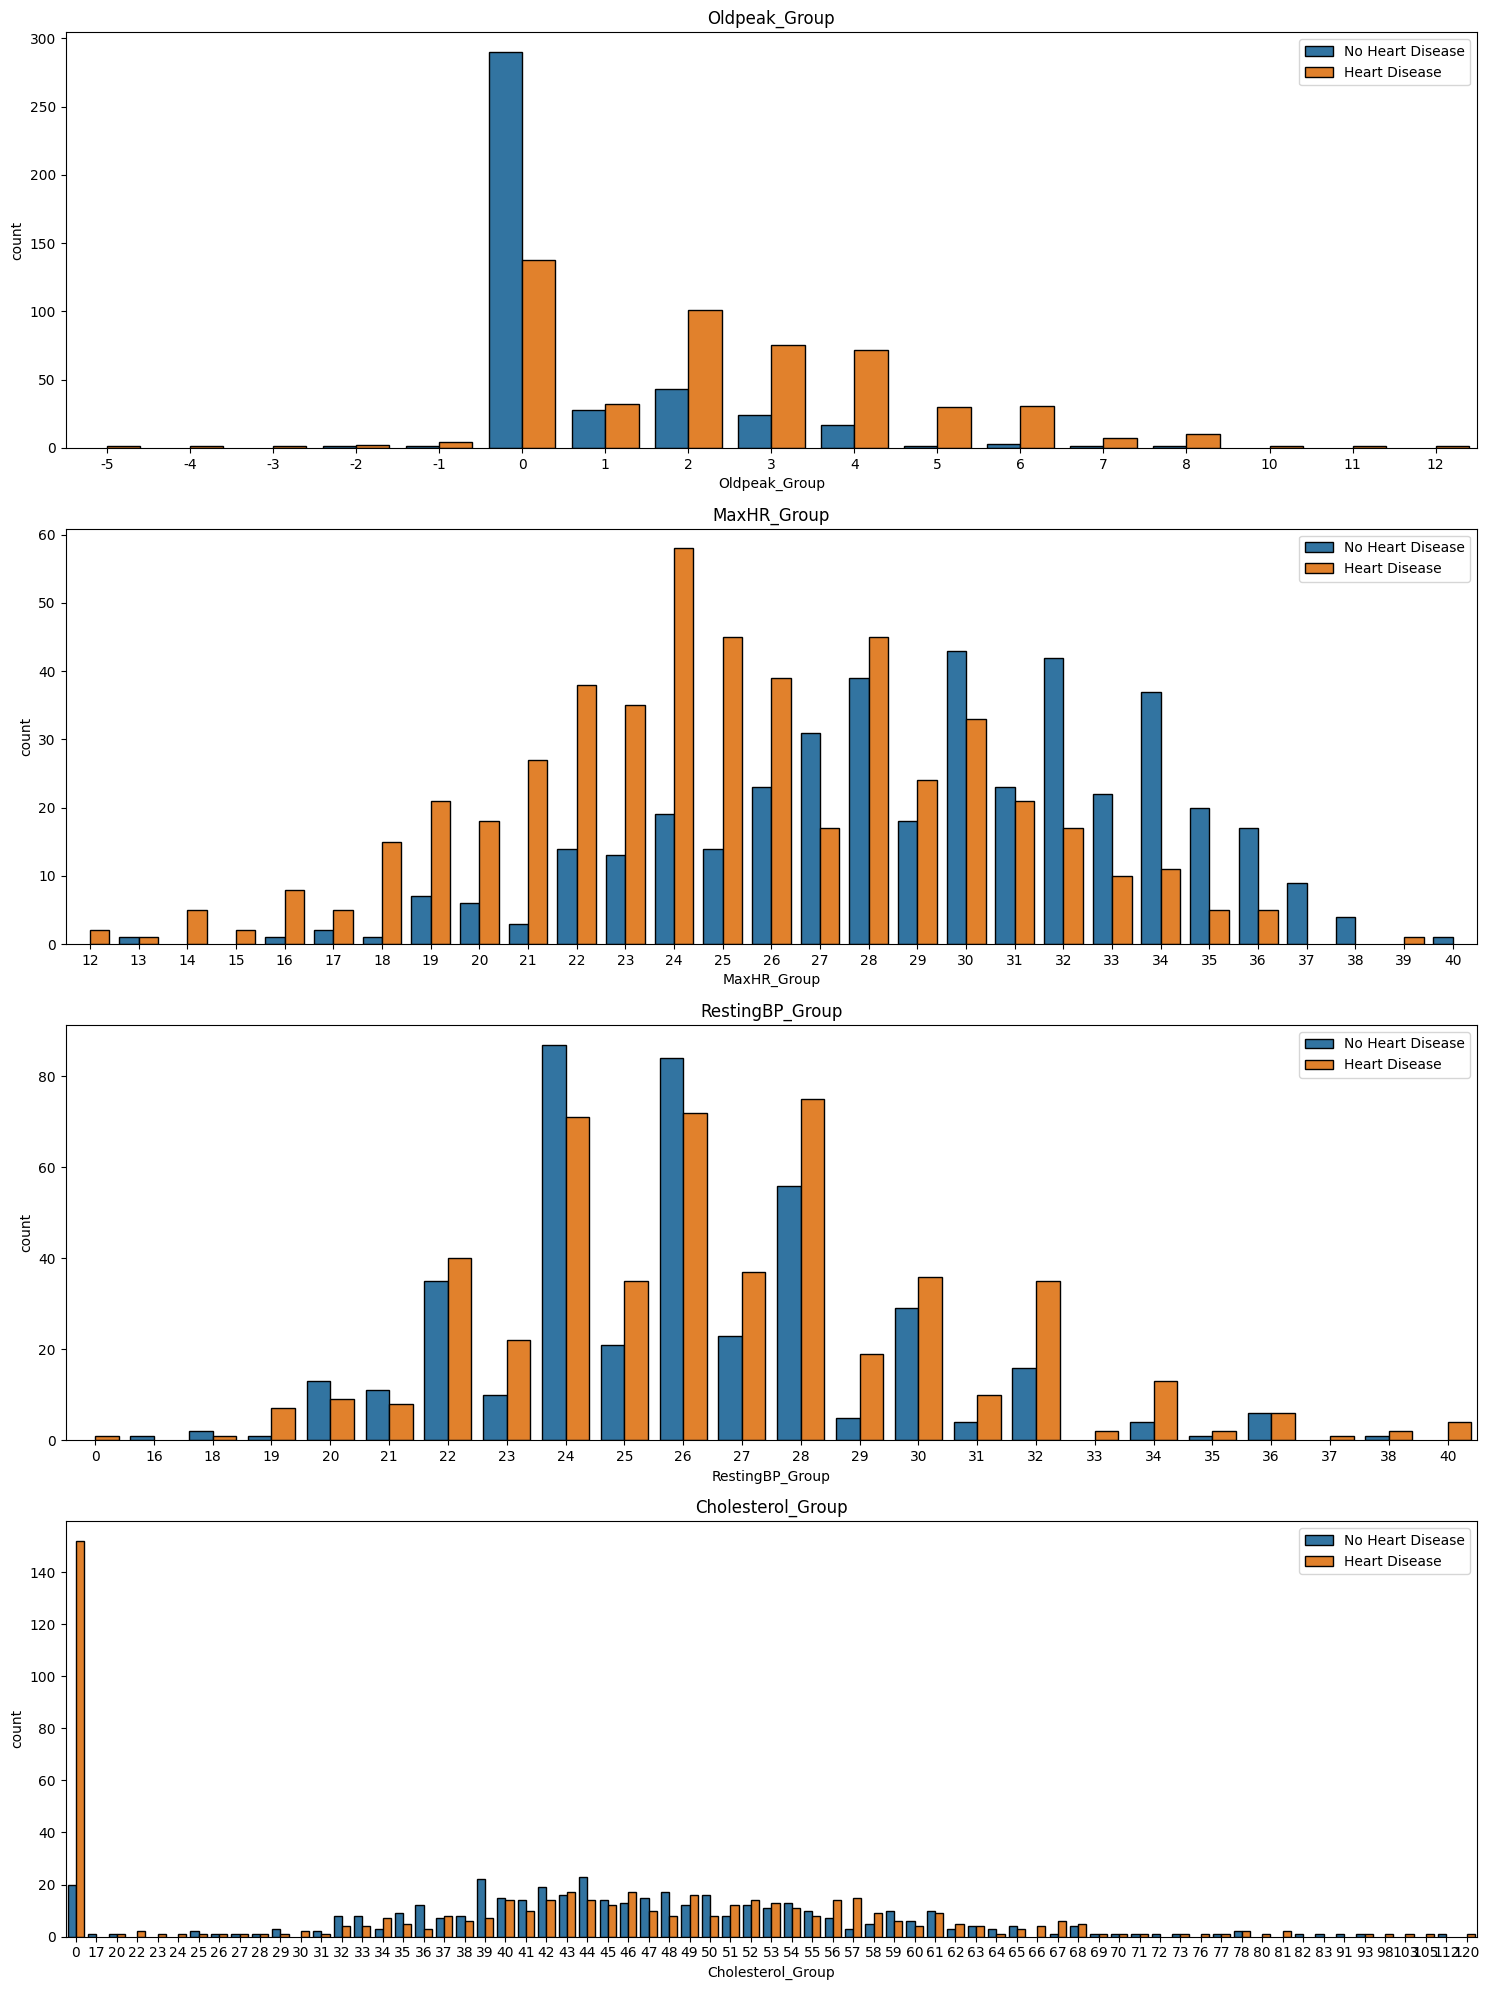

In [15]:
"""
Since it is too difficult to gain any type of insight from this visualisation.
We will convert these numerical features, except age, into categorical features for understandable visualization and gaining insights purposes.
"""

heart_df["Oldpeak_Group"] = [ int((i *10)/ 5) for i in heart_df["Oldpeak"] ]
heart_df["MaxHR_Group"] = [ int(i / 5) for i in heart_df["MaxHR"] ]
heart_df["RestingBP_Group"] = [ int(i / 5) for i in heart_df["RestingBP"] ]
heart_df["Cholesterol_Group"] = [ int(i / 5) for i in heart_df["Cholesterol"] ]

"""
Here, we divided numerical features  MaxHR, RestingBP and Cholesterol by 5 and converted them into integers to group them into bins for easier visualization and analysis.
And, we divided Oldpeak by 5 and converted it into integers to group them into bins for easier visualization and analysis.
"""

group_numerical_features = ["Oldpeak_Group", "MaxHR_Group", "RestingBP_Group", "Cholesterol_Group"]

plt.figure(figsize=(15, 20))
for i, feature in enumerate(group_numerical_features):
  plt.subplot(4, 1, i + 1)
  sns.countplot(x=feature, data=heart_df, hue='HeartDisease', edgecolor = "black")
  plt.legend(['No Heart Disease','Heart Disease'], loc = "upper right")
  plt.title(feature)
  plt.tight_layout()

plt.show()

## Summary of Data Visualisation

Order/Range Positive Cases of Heart Disease

> Categorical Data

- Sex : Male > Female
- Chest Pain Type : ASY > NAP > ATA > TA
- RestingECG : Normal > ST > LVH
- ExerciseAngina : Angina > No Angina
- ST_Slope : Flat > Up > Down


> Numerical Data

- Age : 50+
- RestingBP : 95 - 170
- Cholestrol : 160 - 340
- OldPeak : 0 - 4
- MaxHR : 70 -180

## Data Cleaning

In [16]:
## Data Cleaning
"""
Drop the columns that were grouped
"""

heart_df = heart_df.drop(["Oldpeak_Group", "MaxHR_Group", "RestingBP_Group", "Cholesterol_Group"], axis=1)


"""
During the visualisation, we saw some issues with RestingBP and Cholestrol variables, both having minimum value of 0
"""

heart_df[heart_df["RestingBP"] == 0].info()
heart_df[heart_df["Cholesterol"] == 0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 449 to 449
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1 non-null      int64  
 1   Sex             1 non-null      object 
 2   ChestPainType   1 non-null      object 
 3   RestingBP       1 non-null      int64  
 4   Cholesterol     1 non-null      int64  
 5   FastingBS       1 non-null      int64  
 6   RestingECG      1 non-null      object 
 7   MaxHR           1 non-null      int64  
 8   ExerciseAngina  1 non-null      object 
 9   Oldpeak         1 non-null      float64
 10  ST_Slope        1 non-null      object 
 11  HeartDisease    1 non-null      int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 104.0+ bytes
<class 'pandas.core.frame.DataFrame'>
Index: 172 entries, 293 to 536
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age   

In [17]:
"""
We have 1 patient with RestingBP = 0 which is a dataentry error and can be removed.
We have 172 patients with Cholesterol = 0 which is approximately 19% of our dataset.

Here, we remove the record with RestingBP = 0
and we replace the records with Cholestrol = 0 with the median value
"""

heart_df_clean  = heart_df.copy()

# Keeps only the records with RestingBP != 0
heart_df_clean = heart_df_clean[heart_df_clean["RestingBP"] != 0]

# Create a mask for patients without heart disease
heartdisease_mask = heart_df_clean["HeartDisease"]==0

# Get cholesterol values for patients with and without heart disease
cholesterol_without_heartdisease = heart_df_clean.loc[heartdisease_mask, "Cholesterol"]
cholesterol_with_heartdisease = heart_df_clean.loc[~heartdisease_mask, "Cholesterol"]

# Replace cholesterol = 0 values with the median for the respective group
heart_df_clean.loc[heartdisease_mask, "Cholesterol"] = cholesterol_without_heartdisease.replace(to_replace = 0, value = cholesterol_without_heartdisease.median())
heart_df_clean.loc[~heartdisease_mask, "Cholesterol"] = cholesterol_with_heartdisease.replace(to_replace = 0, value = cholesterol_with_heartdisease.median())

# Verify our cleaning worked
heart_df_clean[["Cholesterol", "RestingBP"]].describe()

,Cholesterol,RestingBP
count,917.000000,917.000000
mean,239.700109,132.540894
std,54.352727,17.999749
min,85.000000,80.000000
25%,214.000000,120.000000
50%,225.000000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


In [18]:
heart_df_clean.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,239.700109,0.233370,136.789531,0.886696,0.552890
std,9.437636,17.999749,54.352727,0.423206,25.467129,1.066960,0.497466
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,225.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Data Preprocessing

In [19]:
heart_df_clean.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [20]:
# Split features and target
X = heart_df_clean.drop("HeartDisease", axis=1)
y = heart_df_clean["HeartDisease"]

In [21]:
# Defining the columns
categorical_cols = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

numerical_cols = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

In [22]:
# One Hot Encoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [ ]:
# # Select Numerical Features and Encode it
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# le = LabelEncoder()

# numerical_features = heart_df_clean.select_dtypes(include=['int64', 'float64'])

# # Select Categorical Features and Encode it
# categorical_features = heart_df_clean.select_dtypes(include=['object'])
# categorical_features_encoded = categorical_features.apply(le.fit_transform)

# #Combine numerical and categorical features
# heart_df_combined = pd.concat([numerical_features, categorical_features_encoded], axis=1)
# print(heart_df_combined.head())

# # Separate features (X) and target variable (y)
# X = heart_df_combined.drop("HeartDisease", axis=1)
# y = heart_df_combined["HeartDisease"]

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  Sex  \
0   40        140          289          0    172      0.0             0    1   
1   49        160          180          0    156      1.0             1    0   
2   37        130          283          0     98      0.0             0    1   
3   48        138          214          0    108      1.5             1    0   
4   54        150          195          0    122      0.0             0    1   

   ChestPainType  RestingECG  ExerciseAngina  ST_Slope  
0              1           1               0         2  
1              2           1               0         1  
2              1           2               0         2  
3              0           1               1         1  
4              2           1               0         2  


In [ ]:
# X = heart_df_clean.drop("HeartDisease", axis=1)
# y = heart_df_clean["HeartDisease"]

In [69]:
# Split the data into training, testing, and validation sets
"""
Here, X (features) and y (target) variable are split into training, testing, and validation sets using the train_test_split function from scikit-learn.
The test_size parameter is set to 0.2, which means that 20% of the data will be used for testing and the remaining 80% will be used for training.
The random_state parameter is set to 42, which ensures that the data is split in a reproducible manner.
The stratify parameter ensures that the split maintains the same proportion of the target variable in both the training and testing sets as in the original dataset.

The test and validation sets are then split from the training set using another train_test_split function.
The test_size parameter is set to 0.5, which means that 50% of the initial test/validation data will be used for the final test set and the remaining 50% will be used for the validation set.
"""

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify = y_test)

# Print the shapes of the resulting sets to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("y_val shape:", y_val.shape)

X_train shape: (733, 11)
X_test shape: (92, 11)
X_val shape: (92, 11)
y_train shape: (733,)
y_test shape: (92,)
y_val shape: (92,)


## Model 1: Logistic Regression
- Logistic Regression is a linear model for binary classification.
- It estimates probabilities of class membership using a linear function.
- Requires feature scaling for best performance.

In [86]:
"""
Scaling is done using StandardScaler to standardize features by removing the mean and scaling to unit variance.
This is applied to the training, validation, and test sets.
This is done to ensure that features are on a similar scale, which is important for many machine learning algorithms.
"""
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [87]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Hyperparameter grid
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],   # regularization strength
    "model__penalty": ["l2"],              # stable for most solvers
    "model__solver": ["lbfgs", "liblinear"]
}

# Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
lr_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

# Train Model
lr_grid_search.fit(X_train, y_train)

print("Best Parameters:", lr_grid_search.best_params_)
print("Best CV Accuracy:", lr_grid_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV Accuracy: 0.8485975212002609


In [88]:
# Predict on the validation set
best_lr_model = lr_grid_search.best_estimator_

# Validation predictions
lr_preds_val = best_lr_model.predict(X_val)

print("Logistic Regression Validation Accuracy:",
      accuracy_score(y_val, lr_preds_val))

print("\nClassification Report (Validation):\n")
print(classification_report(y_val, lr_preds_val))

Logistic Regression Validation Accuracy: 0.8804347826086957

Classification Report (Validation):

              precision    recall  f1-score   support

           0       0.88      0.85      0.86        41
           1       0.88      0.90      0.89        51

    accuracy                           0.88        92
   macro avg       0.88      0.88      0.88        92
weighted avg       0.88      0.88      0.88        92



In [89]:
# Test predictions
lr_preds_test = best_lr_model.predict(X_test)

print("Logistic Regression Test Accuracy:",
      accuracy_score(y_test, lr_preds_test))

print("\nClassification Report (Test):\n")
print(classification_report(y_test, lr_preds_test))


Logistic Regression Test Accuracy: 0.8695652173913043

Classification Report (Test):

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        41
           1       0.88      0.88      0.88        51

    accuracy                           0.87        92
   macro avg       0.87      0.87      0.87        92
weighted avg       0.87      0.87      0.87        92



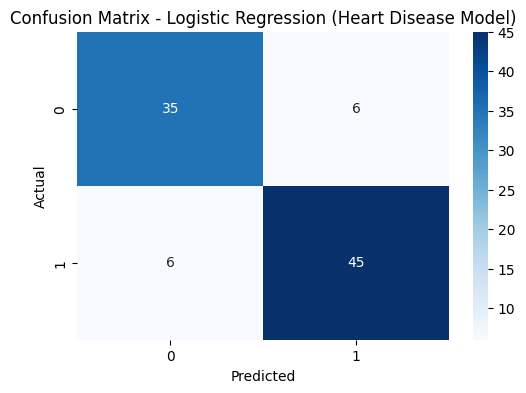

In [90]:
best_lr_model = lr_grid_search.best_estimator_

y_pred = best_lr_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Heart Disease Model)")

plt.show()

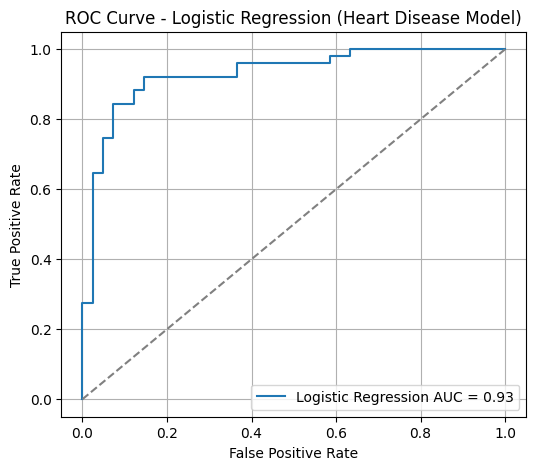

In [91]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get best model
best_lr_model = lr_grid_search.best_estimator_

# Predict probabilities (IMPORTANT)
y_proba = best_lr_model.predict_proba(X_test)[:, 1]

# ROC computation
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Heart Disease Model)")
plt.legend()
plt.grid()

plt.show()

## Model 2: Random Forest Classifier
- Random Forest builds an ensemble of decision trees and aggregates their outputs.
- Reduces overfitting compared to single decision trees.
- Handles both linear and non-linear relationships well.
- Does not require feature scaling.

In [71]:
print(X_train.dtypes)

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
dtype: object


In [72]:
"""
Random Forest Classifier doesn't requires Scaling.
This is because tree-based models make decisions based on the relative order of feature values, which is not affected by scaling.
"""
# Pipeline
from sklearn.pipeline import Pipeline
# Import the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier


pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])



### Simple Model without HyperParameter Tuning

In [74]:
# Train Simple Model
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [75]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9130434782608695
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        41
           1       0.94      0.90      0.92        51

    accuracy                           0.91        92
   macro avg       0.91      0.91      0.91        92
weighted avg       0.91      0.91      0.91        92



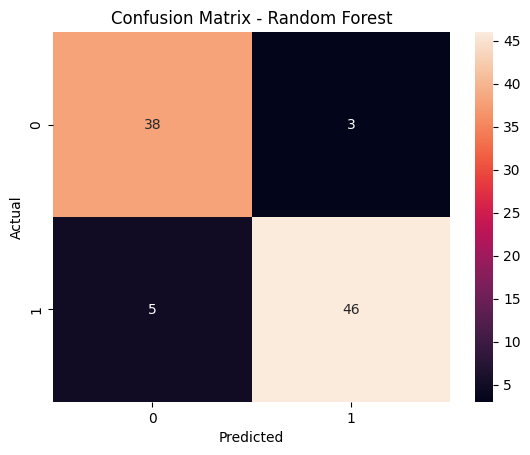

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

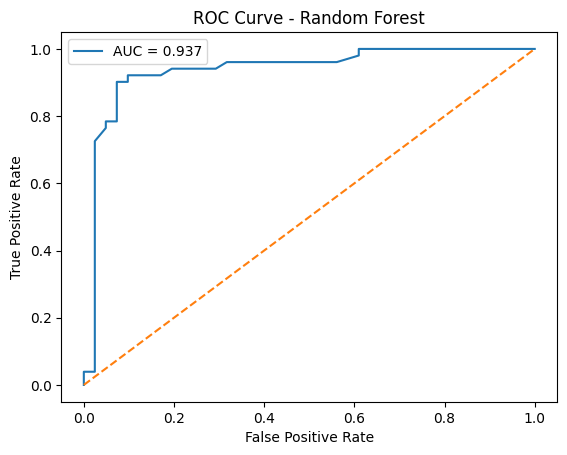

In [77]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

### Training Model with K fold and Grid Search

In [78]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Hyperparameter grid
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
# Stratified K-Fold (important for medical dataset)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)


# Fit on full dataset
rf_grid_search.fit(X_train, y_train)

# Best results
print("Best Parameters:", rf_grid_search.best_params_)
print("Best Cross-Validation Accuracy:", rf_grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best Cross-Validation Accuracy: 0.8581586059081167


In [79]:
# Best model from GridSearchCV
rf_best_model = rf_grid_search.best_estimator_

# Predictions
rf_y_pred = rf_best_model.predict(X_test)
rf_y_proba = rf_best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_y_pred))
print("Classification Report:\n")
print(classification_report(y_test, rf_y_pred))

Accuracy: 0.9130434782608695
Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.90        41
           1       0.94      0.90      0.92        51

    accuracy                           0.91        92
   macro avg       0.91      0.91      0.91        92
weighted avg       0.91      0.91      0.91        92



In [80]:
print("Best Params:", rf_grid_search.best_params_)
print("CV Accuracy:", rf_grid_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_val))

Best Params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
CV Accuracy: 0.8581586059081167
Test Accuracy: 0.5434782608695652


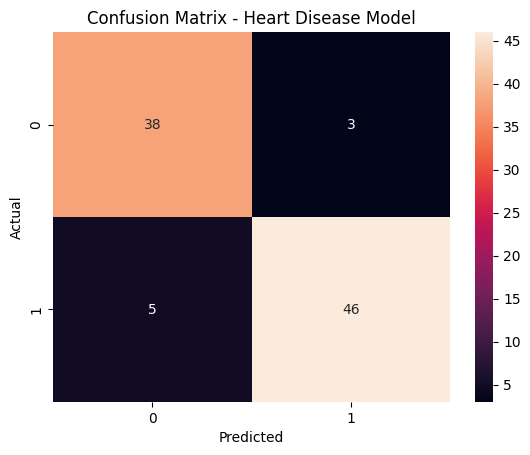

In [82]:
cm = confusion_matrix(y_test, rf_y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Heart Disease Model")
plt.show()

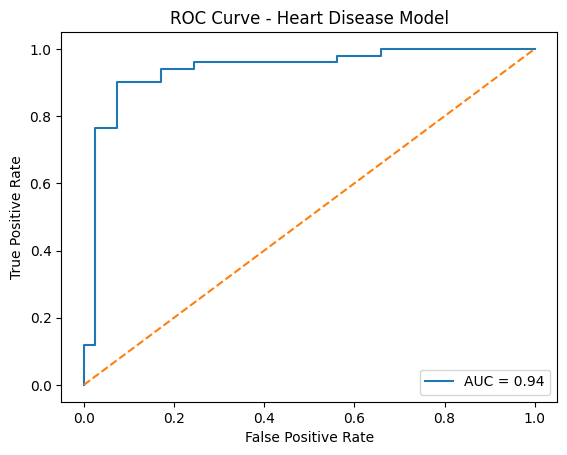

In [85]:
fpr, tpr, thresholds = roc_curve(y_test, rf_y_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Disease Model")
plt.legend()
plt.show()

## Model 4: XGBoost

In [95]:
from xgboost import XGBClassifier

# Create an XGBoost Classifier model
xgb_model = XGBClassifier(random_state=42)

# Train the model using the unscaled training data
xgb_model.fit(X_train, y_train)

# Make predictions on the unscaled validation data
xgb_preds_val = xgb_model.predict(X_val)
print("XGBoost Validation Accuracy:", accuracy_score(y_val, xgb_preds_val))
print(classification_report(y_val, xgb_preds_val))

# Make predictions on the unscaled test data
xgb_preds_test = xgb_model.predict(X_test)
print("XGBoost Test Accuracy:", accuracy_score(y_test, xgb_preds_test))
print(classification_report(y_test, xgb_preds_test))

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Sex: object, ChestPainType: object, RestingECG: object, ExerciseAngina: object, ST_Slope: object

## Confusion Matrix


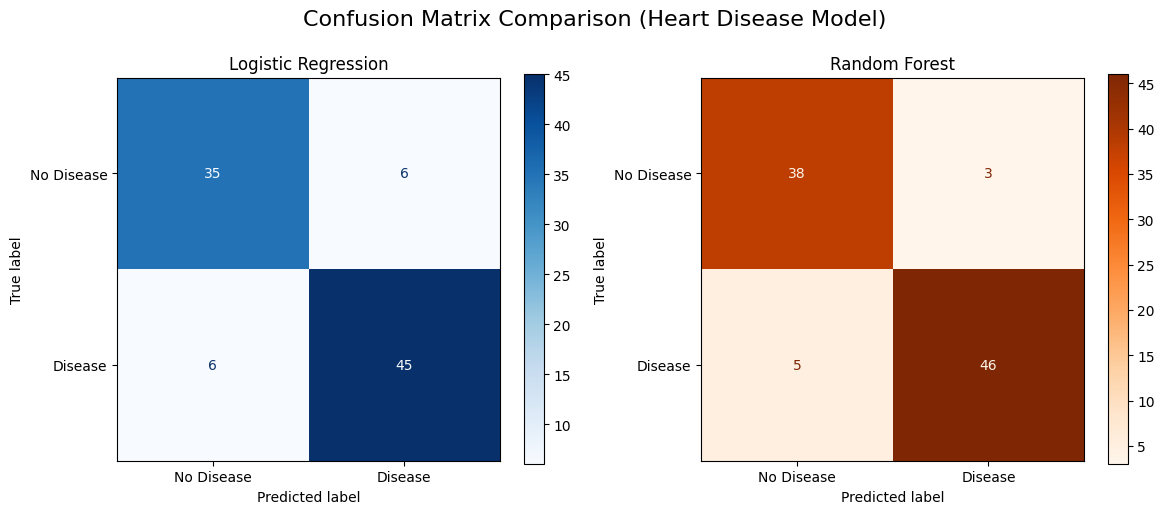

In [92]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Best models
lr_model = lr_grid_search.best_estimator_
rf_model = rf_grid_search.best_estimator_

# Predictions on TEST SET (correct)
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_preds,
    ax=axes[0],
    cmap='Blues',
    values_format='d',
    display_labels=["No Disease", "Disease"]
)
axes[0].set_title("Logistic Regression")

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_preds,
    ax=axes[1],
    cmap='Oranges',
    values_format='d',
    display_labels=["No Disease", "Disease"]
)
axes[1].set_title("Random Forest")

plt.suptitle("Confusion Matrix Comparison (Heart Disease Model)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.show()

Each matrix shows the counts of true positive, true negative, false positive, and false negative predictions.

- True - Negatives (TN) : Correctly predicted no heart disease. It is the top-left cell.
- False - Positive (FP) : Predicted heart disease, but it was wrong (the person didn't have it). It is the top-right cell.
- False - Negatives (FN) : Predicted no heart disease, but it was wrong (the person actually had it). It is the bottom-left cell.
- True - Positive (TP) : Correctly predicted heart disease. It is the bottom-right cell.

---
**Logistic Regression:**
*   TN: 37
*   FP: 4
*   FN: 4
*   TP: 47

This means the model correctly identified `37` cases without heart disease and `47` cases with heart disease. It incorrectly predicted `4` cases as having heart disease (when they didn't) and `4` cases as not having heart disease (when they did).

---


**Random Forest:**
*   TN: 41
*   FP: 0
*   FN: 0
*   TP: 51

This means the model correctly identified `35` cases without heart disease and `47` cases with heart disease. It incorrectly predicted `6` cases as having heart disease (when they didn't) and `4` cases as not having heart disease (when they did).

---




*Based on the confusion matrices, the XGBoost model appears to have the best overall performance. It achieved the highest number of True Negatives and the lowest number of False Positives, while maintaining a high number of True Positives. This indicates that XGBoost not only effectively identified individuals with heart disease but also minimized incorrect predictions of disease in healthy individuals, making it the most balanced model among the ones tested.*

## ROC Curve

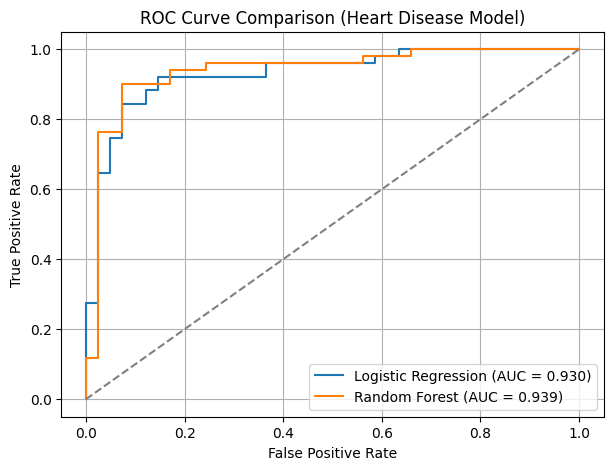

In [93]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Best models
lr_model = lr_grid_search.best_estimator_
rf_model = rf_grid_search.best_estimator_

# Probabilities (TEST SET only)
lr_probs = lr_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# AUC scores
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

# Plot
plt.figure(figsize=(7, 5))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Heart Disease Model)")
plt.legend()
plt.grid()

plt.show()

# Save the Model

In [94]:
import joblib

joblib.dump(rf_best_model, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [96]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

# Testing

In [97]:
import joblib

model = joblib.load("heart_disease_model.pkl")

In [98]:
import pandas as pd

sample = pd.DataFrame([{
    "Age": 55,
    "Sex": "M",
    "ChestPainType": "ATA",
    "RestingBP": 140,
    "Cholesterol": 220,
    "FastingBS": 0,
    "RestingECG": "Normal",
    "MaxHR": 150,
    "ExerciseAngina": "N",
    "Oldpeak": 1.2,
    "ST_Slope": "Up"
}])

In [99]:
prediction = model.predict(sample)
probability = model.predict_proba(sample)

print("Prediction:", prediction[0])
print("Probability (No Disease, Disease):", probability[0])

Prediction: 0
Probability (No Disease, Disease): [0.86456746 0.13543254]


In [100]:
import pandas as pd

sample_low_risk = pd.DataFrame([{
    "Age": 30,
    "Sex": "F",
    "ChestPainType": "ASY",   # no typical angina
    "RestingBP": 110,
    "Cholesterol": 180,
    "FastingBS": 0,
    "RestingECG": "Normal",
    "MaxHR": 170,
    "ExerciseAngina": "N",
    "Oldpeak": 0.0,
    "ST_Slope": "Up"
}])

In [101]:
prediction = model.predict(sample_low_risk)
probability = model.predict_proba(sample_low_risk)

print("Prediction:", prediction[0])
print("Probability (No Disease, Disease):", probability[0])


Prediction: 0
Probability (No Disease, Disease): [0.91985714 0.08014286]


In [102]:
import pandas as pd

sample_high_risk = pd.DataFrame([{
    "Age": 65,
    "Sex": "M",
    "ChestPainType": "ASY",      # asymptomatic but dangerous pattern
    "RestingBP": 170,
    "Cholesterol": 320,
    "FastingBS": 1,
    "RestingECG": "ST",          # abnormal ECG
    "MaxHR": 105,
    "ExerciseAngina": "Y",
    "Oldpeak": 3.2,              # strong ST depression
    "ST_Slope": "Down"           # worst slope pattern
}])

In [103]:
prediction = model.predict(sample_high_risk)
probability = model.predict_proba(sample_high_risk)

print("Prediction:", prediction[0])
print("Probability (No Disease, Disease):", probability[0])

Prediction: 1
Probability (No Disease, Disease): [0.13174405 0.86825595]


In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Best models
lr_model = lr_grid_search.best_estimator_
rf_model = rf_grid_search.best_estimator_

# Predictions
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Probabilities (for AUC)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Logistic Regression Metrics
lr_metrics = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1-Score": f1_score(y_test, lr_pred),
    "ROC-AUC Score": roc_auc_score(y_test, lr_proba)
}

# Random Forest Metrics
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1-Score": f1_score(y_test, rf_pred),
    "ROC-AUC Score": roc_auc_score(y_test, rf_proba)
}

# Create comparison table
df = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics
})

print(df)

               Logistic Regression  Random Forest
Accuracy                  0.869565       0.913043
Precision                 0.882353       0.938776
Recall                    0.882353       0.901961
F1-Score                  0.882353       0.920000
ROC-AUC Score             0.930177       0.938785


# THE END